Dataset shape: (569, 30)
Training set: (455, 30)
Testing set: (114, 30)
Feature scaling completed
Linear SVM trained successfully

Linear SVM Predictions:
[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]

Nonlinear SVM trained successfully

RBF SVM Predictions:
[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]

Accuracy:
Linear SVM Accuracy: 0.956140350877193
RBF SVM Accuracy: 0.9824561403508771

Linear SVM
Precision: 0.9714285714285714
Recall: 0.9577464788732394
F1-Score: 0.9645390070921985

RBF SVM
Precision: 0.9726027397260274
Recall: 1.0
F1-Score: 0.9861111111111112

Linear SVM Confusion Matrix:
[[41  2]
 [ 3 68]]

RBF SV

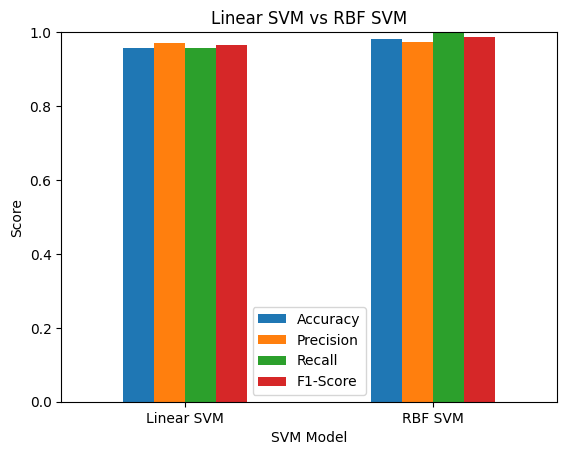

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset shape:", X.shape)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed")

# Linear SVM
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

print("Linear SVM trained successfully")

# Linear SVM prediction
y_pred_linear = linear_model.predict(X_test)

print("\nLinear SVM Predictions:")
print(y_pred_linear)

# RBF SVM
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

print("\nNonlinear SVM trained successfully")

# RBF SVM prediction
y_pred_rbf = rbf_model.predict(X_test)

print("\nRBF SVM Predictions:")
print(y_pred_rbf)

# Accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("\nAccuracy:")
print("Linear SVM Accuracy:", accuracy_linear)
print("RBF SVM Accuracy:", accuracy_rbf)

# Precision, Recall, F1-Score
print("\nLinear SVM")
print("Precision:", precision_score(y_test, y_pred_linear))
print("Recall:", recall_score(y_test, y_pred_linear))
print("F1-Score:", f1_score(y_test, y_pred_linear))

print("\nRBF SVM")
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall:", recall_score(y_test, y_pred_rbf))
print("F1-Score:", f1_score(y_test, y_pred_rbf))

# Confusion Matrix
print("\nLinear SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

print("\nRBF SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

# Results table
results = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM"],
    "Accuracy": [
        accuracy_linear,
        accuracy_rbf
    ],
    "Precision": [
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf)
    ]
})

print("\nComparison Results:")
print(results)

# Visualization
results.set_index("Model").plot(kind="bar")
plt.title("Linear SVM vs RBF SVM")
plt.ylabel("Score")
plt.xlabel("SVM Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()